# 5.2 Photometry of Saturated Stars - Under construction!

In [6]:
#!/usr/bin/env Python3

%matplotlib inline
%matplotlib notebook

import os
import warnings
import numpy as np
import matplotlib.pyplot as plt

from scipy import constants

from platosim.simulation import Simulation
from platosim.plot import drawCCDsInCameraFocalPlane
from platosim.utilities import passbandConversionV2P, NSRphotonNoiseLimit

# Change default settings

warnings.simplefilter("ignore")
plt.rcParams['text.usetex'] = True
plt.rc('xtick', labelsize=15) 
plt.rc('ytick', labelsize=15) 
plt.rcParams.update({'font.size': 15})

## Load data

In [2]:
# LOAD AND CREATE USER DEFINED STAR CATALOGUE

# Loading PIC targets
pic_tar = np.loadtxt(os.getcwd() + '/starcat-SPF-P2-Targets.txt')
ID  = pic_tar[:,0].astype(int)
ra  = pic_tar[:,1]
dec = pic_tar[:,2]
mag = pic_tar[:,3]

# Loading PIC contaminants
pic_con = np.loadtxt(os.getcwd() + '/starcat-SPF-P2-Contaminants.txt')
ID_con   = pic_con[:,0].astype(int)
ra_con   = pic_con[:,1]
dec_con  = pic_con[:,2]
mag_con  = pic_con[:,3]

## Plot point-like ghost on the CCDs

<IPython.core.display.Javascript object>


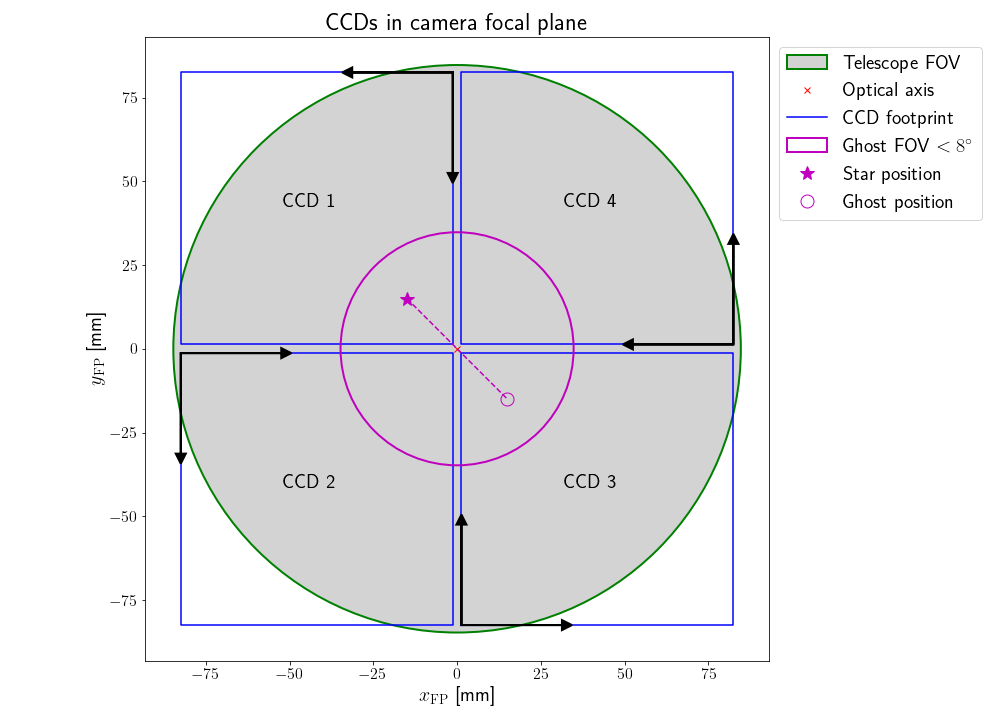

In [4]:
# Instrumental parameters

pixelSize   = 18        # [µm]
plateScale  = 15        # [arcsec]
fovGhost    = 8.0       # [deg]
focalLength = 247.52    # [mm]

# Calculate the maximum FOV for a point-like ghost creation

fovGhost = focalLength * np.tan(np.radians(fovGhost))  # [mm]

# START PLOT

fig = plt.figure(figsize=(14,10))

# Plotting

ax = drawCCDsInCameraFocalPlane(fig)
c = plt.Circle((0, 0), radius=fovGhost, color="none", linewidth=2, label=r"Ghost FOV $<8^{\circ}$", zorder=4)
c.set_edgecolor("m")
ax.add_patch(c)
ax.plot(-15, 15, '*', c='m', ms=15, label='Star position', zorder=5)
ax.plot(15, -15, 'o', c='m', ms=13, fillstyle="none", label='Ghost position', zorder=6)
ax.plot([-15, 15], [15, -15], '--', c='m', zorder=7)

# Settings

plt.legend(prop={'size':20}, bbox_to_anchor=(1.0,1.0))
ax.set_aspect('equal', 'box')
plt.tight_layout()

plt.show()

# Save figrue
plt.rcParams['text.usetex'] = True

fig.savefig(os.getcwd() + '/plotGhostInFocalPlane.png', dpi=300)

## Plot ghost irradiance vs. magnitude 

<IPython.core.display.Javascript object>


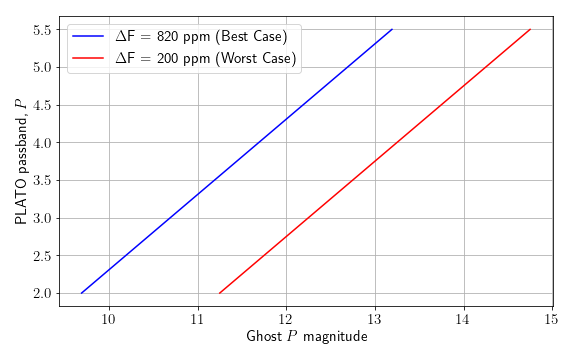

In [16]:
# User defined params:

Teff = 6000
P = np.arange(2.0, 6.0, 0.5)

# Find ghost magnitude

Pg_BC = P + 2.5*np.log10(1/0.00084)
Pg_WC = P + 2.5*np.log10(1/0.00020)

# Start plot

fig = plt.figure(figsize=(8,5))

plt.plot(Pg_BC, P, 'b-', label=r'$\Delta$F = 820 ppm (Best  Case)')
plt.plot(Pg_WC, P, 'r-', label=r'$\Delta$F = 200 ppm (Worst Case)')

plt.xlabel('Ghost $P$ magnitude')
plt.ylabel(r'PLATO passband, $P$')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

fig.savefig(os.getcwd() + '/plot_ghost_magnitude.png', dpi=300)